# 03 — Visualization

This notebook translates the SQL findings from `02_sql_analysis.ipynb` into charts for the final report.  
Each chart is designed to support a specific business finding — not just to display data, but to make the conclusion visually undeniable.

**Charts:**
1. Profit margin by region — establishes that Central is the problem region
2. Average discount by region — shows discounting as the likely cause
3. Profit by sub-category (Central only) — identifies the specific loss-makers
4. Discount vs profit scatter (Central only) — shows the 20% empirical breakeven
5. High discount rate vs profit margin by state — statistical validation (r = −0.905)
6. Discount by region for Group A sub-categories — proves Central's over-discounting is region-specific, not product-level

All charts are saved to `../report/` for use in the PDF report.

In [75]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../data/superstore.db")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Ready to visualize!")

Ready to visualize!


## Chart 1 — Profit Margin by Region

**Finding:** Central has a 7.92% margin, nearly half of West's 14.94%.  
We use colour to highlight the outliers (green = best, red = worst) so the reader's eye goes directly to the problem.

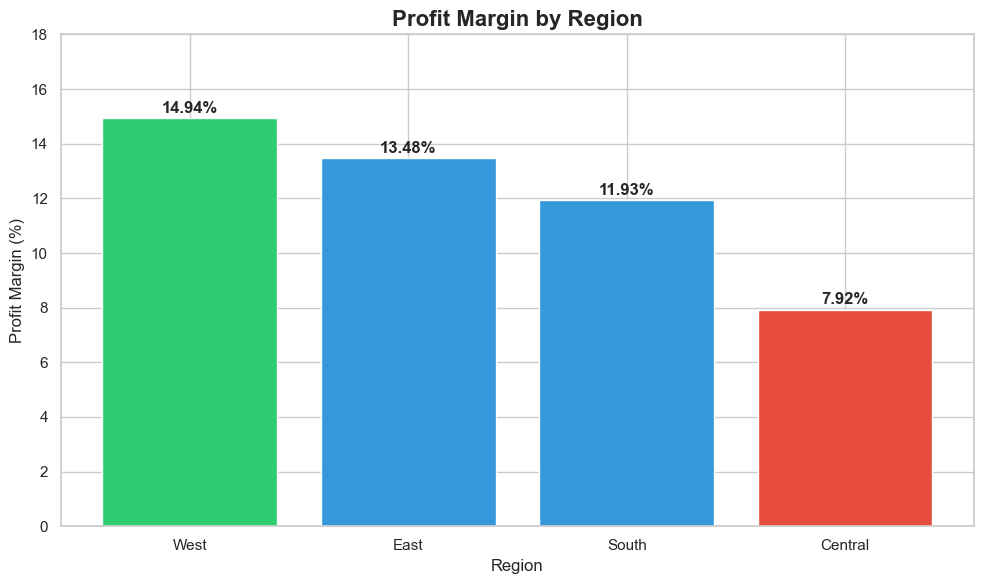

✅ Chart 1 saved!


In [76]:
# Get data from database
query = """
    SELECT 
        Region,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 2) AS profit_margin_pct
    FROM orders
    GROUP BY Region
    ORDER BY profit_margin_pct DESC
"""
region_margin_df = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots()

colors = ["#2ecc71" if x == region_margin_df["profit_margin_pct"].max() 
          else "#e74c3c" if x == region_margin_df["profit_margin_pct"].min() 
          else "#3498db" for x in region_margin_df["profit_margin_pct"]]

bars = ax.bar(region_margin_df["Region"], 
              region_margin_df["profit_margin_pct"], 
              color=colors)

# Add value labels on top of each bar
for bar, val in zip(bars, region_margin_df["profit_margin_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.2, 
            f"{val}%", 
            ha="center", fontweight="bold")

ax.set_title("Profit Margin by Region", fontsize=16, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Profit Margin (%)")
ax.set_ylim(0, 18)

plt.tight_layout()
plt.savefig("../report/chart1_region_margin.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

## Chart 2 — Average Discount by Region

**Hypothesis test:** If discounting is causing Central's low margin, we would expect Central to have a significantly higher average discount.  
The chart confirms this — Central's 24% average discount is more than double West's 11%.

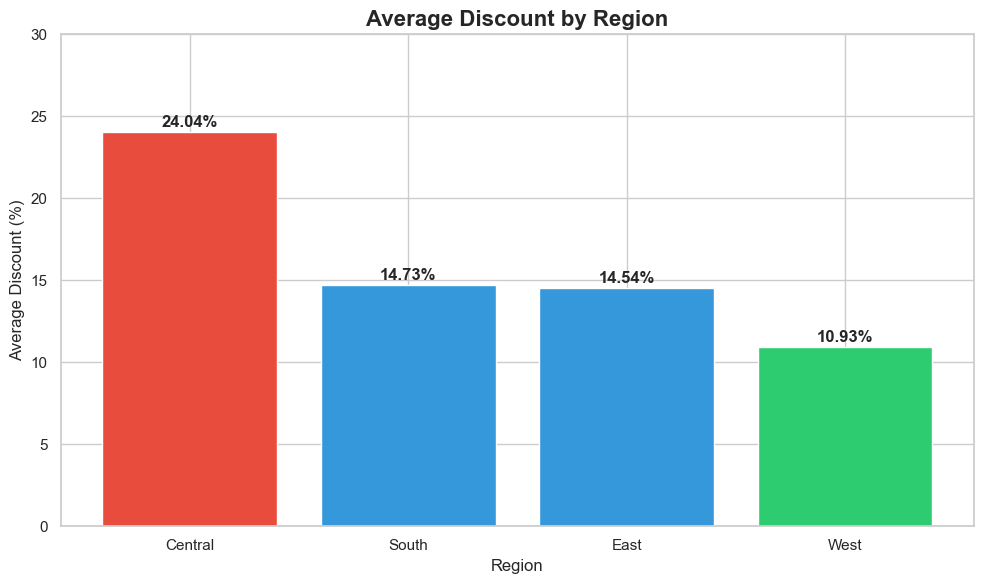

✅ Chart 2 saved!


In [77]:
# Get data
query = """
    SELECT 
        Region,
        ROUND(AVG(Discount) * 100, 2) AS avg_discount_pct
    FROM orders
    GROUP BY Region
    ORDER BY avg_discount_pct DESC
"""
discount_df = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots()

colors = ["#e74c3c" if x == discount_df["avg_discount_pct"].max() 
          else "#2ecc71" if x == discount_df["avg_discount_pct"].min() 
          else "#3498db" for x in discount_df["avg_discount_pct"]]

bars = ax.bar(discount_df["Region"], 
              discount_df["avg_discount_pct"], 
              color=colors)

# Add value labels
for bar, val in zip(bars, discount_df["avg_discount_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val}%",
            ha="center", fontweight="bold")

ax.set_title("Average Discount by Region", fontsize=16, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Average Discount (%)")
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("../report/chart2_region_discount.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

## Chart 3 — Profit by Sub-Category (Central Only)

**Finding:** 7 out of 17 sub-categories are losing money in Central. Furniture is the most problematic category — 3 out of 4 sub-categories are unprofitable.  
A horizontal bar chart works better here than a vertical one because sub-category names are long and would overlap on the x-axis.

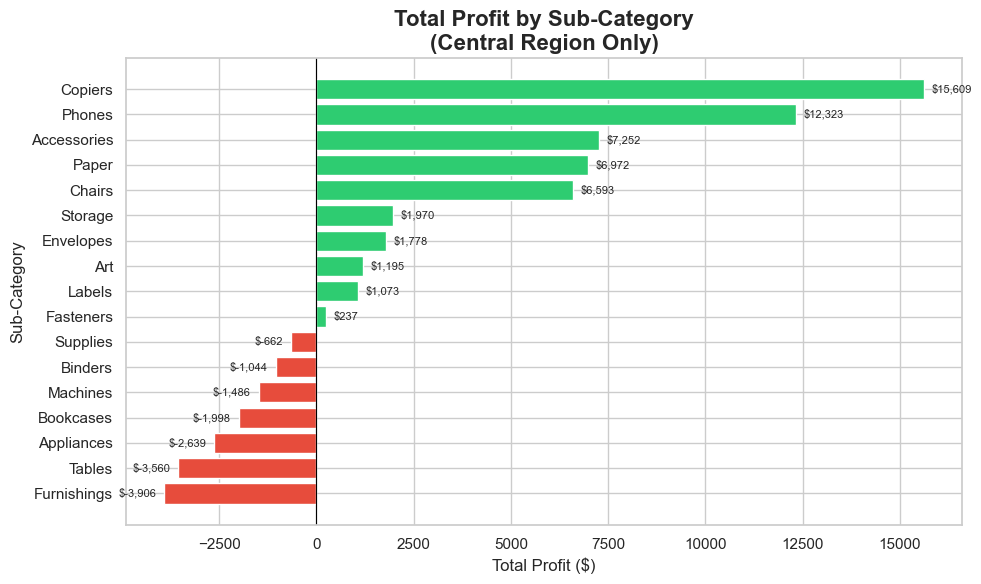

✅ Chart 3 saved!


In [78]:
# Get data
query = """
    SELECT 
        `Sub-Category`,
        ROUND(SUM(Profit), 2) AS total_profit,
        ROUND(AVG(Discount) * 100, 2) AS avg_discount_pct
    FROM orders
    WHERE Region = 'Central'
    GROUP BY `Sub-Category`
    ORDER BY total_profit ASC
"""
subcategory_df = pd.read_sql(query, conn)

# Split into losing and profitable
losing = subcategory_df[subcategory_df["total_profit"] < 0]
profitable = subcategory_df[subcategory_df["total_profit"] >= 0]

# Plot
fig, ax = plt.subplots()

colors = ["#e74c3c" if x < 0 else "#2ecc71" 
          for x in subcategory_df["total_profit"]]

bars = ax.barh(subcategory_df["Sub-Category"],
               subcategory_df["total_profit"],
               color=colors)

# Add value labels
for bar, val in zip(bars, subcategory_df["total_profit"]):
    ax.text(val + (200 if val >= 0 else -200),
            bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=8)

# Add vertical line at 0
ax.axvline(x=0, color="black", linewidth=0.8)

ax.set_title("Total Profit by Sub-Category\n(Central Region Only)", 
             fontsize=16, fontweight="bold")
ax.set_xlabel("Total Profit ($)")
ax.set_ylabel("Sub-Category")

plt.tight_layout()
plt.savefig("../report/chart3_central_subcategory.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

## Chart 4 — Discount vs Profit Scatter (Central Only)

**Finding:** Orders with discounts above 20% cluster heavily below the zero-profit line across all categories.  
The 20% threshold line is drawn based on the empirical breakeven identified in `02_sql_analysis.ipynb` Step 3a — where average profit first turns negative in the 21–30% discount bucket.

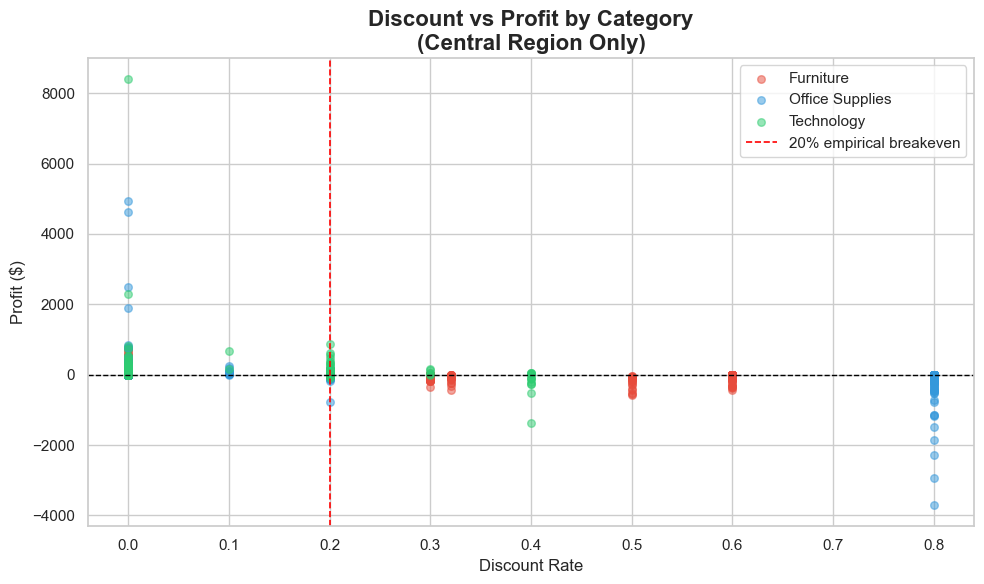

✅ Chart 4 saved!


In [79]:
# Get data
query = """
    SELECT 
        Discount,
        Profit,
        Category
    FROM orders
    WHERE Region = 'Central'
"""
scatter_df = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots()

colors = {"Furniture": "#e74c3c", 
          "Office Supplies": "#3498db", 
          "Technology": "#2ecc71"}

for category, group in scatter_df.groupby("Category"):
    ax.scatter(group["Discount"], 
               group["Profit"],
               label=category,
               color=colors[category],
               alpha=0.5,
               s=30)

ax.axhline(y=0, color="black", linewidth=1, linestyle="--")
ax.axvline(x=0.2, color="red", linewidth=1.2,
           linestyle="--", label="20% empirical breakeven")

ax.set_title("Discount vs Profit by Category\n(Central Region Only)", 
             fontsize=16, fontweight="bold")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit ($)")
ax.legend()

plt.tight_layout()
plt.savefig("../report/chart4_discount_vs_profit.png", dpi=150)
plt.show()
print("✅ Chart 4 saved!")

## Statistical Validation: Discount vs Profit Correlation

The scatter plot above visually suggests that higher discounts lead to lower profit. Here we quantify this relationship with a Pearson correlation test.

In [80]:
from scipy import stats

# Pearson correlation: Discount vs Profit (Central region)
r, p_value = stats.pearsonr(scatter_df["Discount"], scatter_df["Profit"])

print("=" * 45)
print("  Pearson Correlation: Discount vs Profit")
print("  (Central Region)")
print("=" * 45)
print(f"  r  = {r:.4f}")
print(f"  p  = {p_value:.2e}")
print()

if abs(r) >= 0.5:
    strength = "strong"
elif abs(r) >= 0.3:
    strength = "moderate"
else:
    strength = "weak"

direction = "negative" if r < 0 else "positive"
sig = "statistically significant" if p_value < 0.05 else "not statistically significant"

print(f"  Interpretation:")
print(f"  There is a {strength} {direction} correlation between")
print(f"  discount and profit (r = {r:.2f}), and the result")
print(f"  is {sig} (p < 0.05)." if p_value < 0.05 else f"  is {sig}.")
print()
print("  → Higher discounts are associated with lower profit.")
print("    This supports Finding 4 with statistical evidence.")

  Pearson Correlation: Discount vs Profit
  (Central Region)
  r  = -0.2254
  p  = 3.91e-28

  Interpretation:
  There is a weak negative correlation between
  discount and profit (r = -0.23), and the result
  is statistically significant (p < 0.05).

  → Higher discounts are associated with lower profit.
    This supports Finding 4 with statistical evidence.


## Chart 5 — High Discount Rate vs Profit Margin (State Level)

**Finding:** Across 45 US states, states with a higher share of heavily-discounted orders (> 20%) consistently show lower profit margins (r = −0.905, p < 0.0001).

This chart visualises the statistical validation from Step 3c in `02_sql_analysis.ipynb`. Each dot is one state; the trend line confirms the direction and strength of the association. States in the top-right quadrant are both high-discount and unprofitable — the most critical targets.

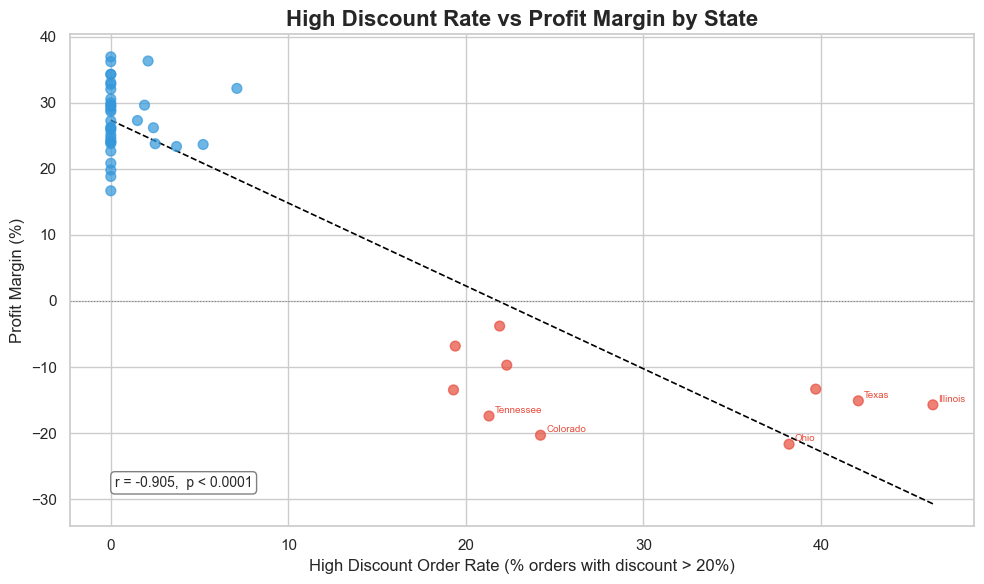

✅ Chart 5 saved!


In [81]:
from scipy import stats
import numpy as np

query = """
    SELECT
        State,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 2) AS profit_margin_pct,
        ROUND(CAST(COUNT(CASE WHEN Discount > 0.2 THEN 1 END) AS REAL) / COUNT(*) * 100, 1) AS high_discount_rate_pct
    FROM orders
    GROUP BY State
    HAVING COUNT(*) >= 10
"""
state_df = pd.read_sql(query, conn)

r, p_value = stats.pearsonr(state_df["high_discount_rate_pct"], state_df["profit_margin_pct"])

# Trend line
x = state_df["high_discount_rate_pct"]
y = state_df["profit_margin_pct"]
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots()

# Colour by margin (red = negative, blue = positive)
point_colors = ["#e74c3c" if v < 0 else "#3498db" for v in y]
ax.scatter(x, y, c=point_colors, alpha=0.7, s=50, zorder=3)

# Trend line
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2, linestyle="--")

# Zero profit reference
ax.axhline(y=0, color="grey", linewidth=0.8, linestyle=":")

# Annotate worst states
worst = state_df.nsmallest(5, "profit_margin_pct")
for _, row in worst.iterrows():
    ax.annotate(row["State"],
                xy=(row["high_discount_rate_pct"], row["profit_margin_pct"]),
                xytext=(4, 2), textcoords="offset points", fontsize=7, color="#e74c3c")

# r annotation
ax.text(0.05, 0.08, f"r = {r:.3f},  p < 0.0001",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="grey"))

ax.set_title("High Discount Rate vs Profit Margin by State", fontsize=16, fontweight="bold")
ax.set_xlabel("High Discount Order Rate (% orders with discount > 20%)")
ax.set_ylabel("Profit Margin (%)")

plt.tight_layout()
plt.savefig("../report/chart5_state_discount_vs_margin.png", dpi=150)
plt.show()
print("✅ Chart 5 saved!")

# Chart5b
The graph below is for one-page report

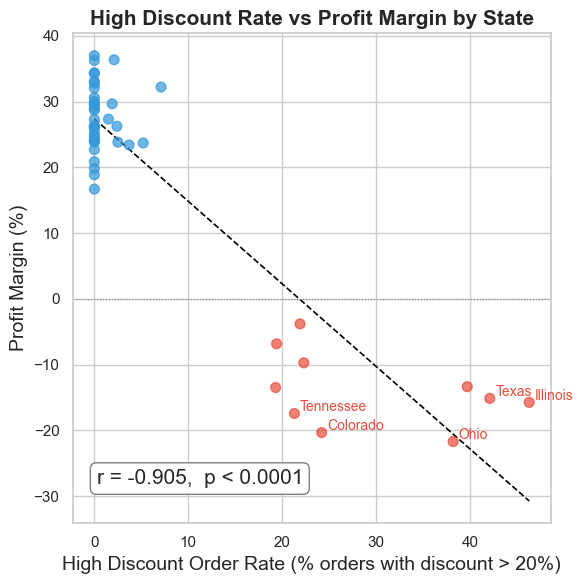

✅ Chart 5 saved!


In [82]:
from scipy import stats
import numpy as np

query = """
    SELECT
        State,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 2) AS profit_margin_pct,
        ROUND(CAST(COUNT(CASE WHEN Discount > 0.2 THEN 1 END) AS REAL) / COUNT(*) * 100, 1) AS high_discount_rate_pct
    FROM orders
    GROUP BY State
    HAVING COUNT(*) >= 10
"""
state_df = pd.read_sql(query, conn)

r, p_value = stats.pearsonr(state_df["high_discount_rate_pct"], state_df["profit_margin_pct"])

# Trend line
x = state_df["high_discount_rate_pct"]
y = state_df["profit_margin_pct"]
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(6, 6))

# Colour by margin (red = negative, blue = positive)
point_colors = ["#e74c3c" if v < 0 else "#3498db" for v in y]
ax.scatter(x, y, c=point_colors, alpha=0.7, s=50, zorder=3)

# Trend line
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2, linestyle="--")

# Zero profit reference
ax.axhline(y=0, color="grey", linewidth=0.8, linestyle=":")

# Annotate worst states
worst = state_df.nsmallest(5, "profit_margin_pct")
for _, row in worst.iterrows():
    ax.annotate(row["State"],
                xy=(row["high_discount_rate_pct"], row["profit_margin_pct"]),
                xytext=(4, 2), textcoords="offset points", fontsize=10, color="#e74c3c")

# r annotation
ax.text(0.05, 0.08, f"r = {r:.3f},  p < 0.0001",
        transform=ax.transAxes, fontsize=15,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="grey"))

ax.set_title("High Discount Rate vs Profit Margin by State", fontsize=15, fontweight="bold")
ax.set_xlabel("High Discount Order Rate (% orders with discount > 20%)",fontsize=14)
ax.set_ylabel("Profit Margin (%)",fontsize=14)

plt.tight_layout()
plt.savefig("../report/chart5_state_discount_vs_margin_b.png", dpi=150)
plt.show()
print("✅ Chart 5 saved!")

## Chart 6 — Discount by Region for Group A Sub-Categories

**Finding (Step 5 of 02_sql_analysis):** Three sub-categories — Appliances, Furnishings, and Binders — are losing money in Central because Central discounts them at dramatically higher rates than any other region. Other regions sell the same products profitably.

This chart makes the contrast visually undeniable: the bars for Central are 5–10× taller than other regions for Appliances and Furnishings. This points directly to a **Central-specific discount policy failure**, not a product-level issue.

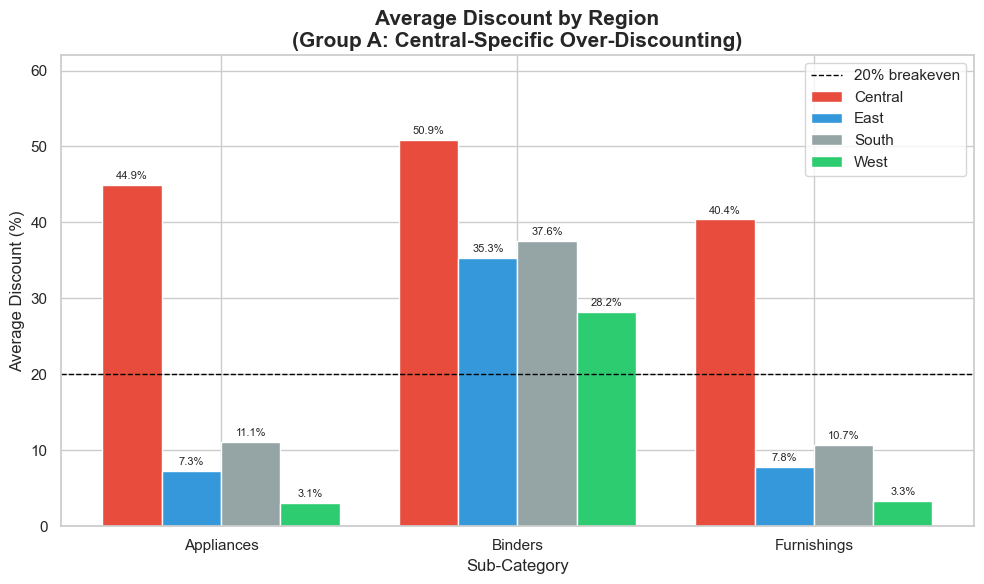

✅ Chart 6 saved!


In [83]:
group_a = ('Appliances', 'Furnishings', 'Binders')

query = f"""
    SELECT
        `Sub-Category`,
        Region,
        ROUND(AVG(Discount) * 100, 1) AS avg_discount_pct
    FROM orders
    WHERE `Sub-Category` IN {group_a}
    GROUP BY `Sub-Category`, Region
"""
group_a_df = pd.read_sql(query, conn)

pivot = group_a_df.pivot(index="Sub-Category", columns="Region", values="avg_discount_pct")
pivot = pivot[["Central", "East", "South", "West"]]  # fix column order

x = np.arange(len(pivot))
width = 0.2
region_colors = {"Central": "#e74c3c", "East": "#3498db", "South": "#95a5a6", "West": "#2ecc71"}

fig, ax = plt.subplots()

for i, region in enumerate(["Central", "East", "South", "West"]):
    bars = ax.bar(x + i * width, pivot[region], width,
                  label=region, color=region_colors[region])
    for bar, val in zip(bars, pivot[region]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val}%", ha="center", va="bottom", fontsize=8)

# 20% breakeven line
ax.axhline(y=20, color="black", linewidth=1, linestyle="--", label="20% breakeven")

ax.set_title("Average Discount by Region\n(Group A: Central-Specific Over-Discounting)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Sub-Category")
ax.set_ylabel("Average Discount (%)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(pivot.index)
ax.legend()
ax.set_ylim(0, 62)

plt.tight_layout()
plt.savefig("../report/chart6_group_a_discount_by_region.png", dpi=150)
plt.show()
print("✅ Chart 6 saved!")

In [84]:
conn.close()
print("✅ All done! Connection closed.")

✅ All done! Connection closed.
